In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
country=pd.read_csv("Country_wise_latest.csv")

In [5]:
day=pd.read_csv("day_wise.csv")

In [6]:
complete=pd.read_csv("covid_19_clean_complete.csv")

In [7]:
country.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [8]:
day.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


In [9]:
complete.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [10]:
print("Country dataset shape:",country.shape)

Country dataset shape: (187, 15)


In [11]:
print("Day dataset shape:", day.shape)

Day dataset shape: (188, 12)


In [12]:
print("Complete dataset shape:",complete.shape)

Complete dataset shape: (49068, 10)


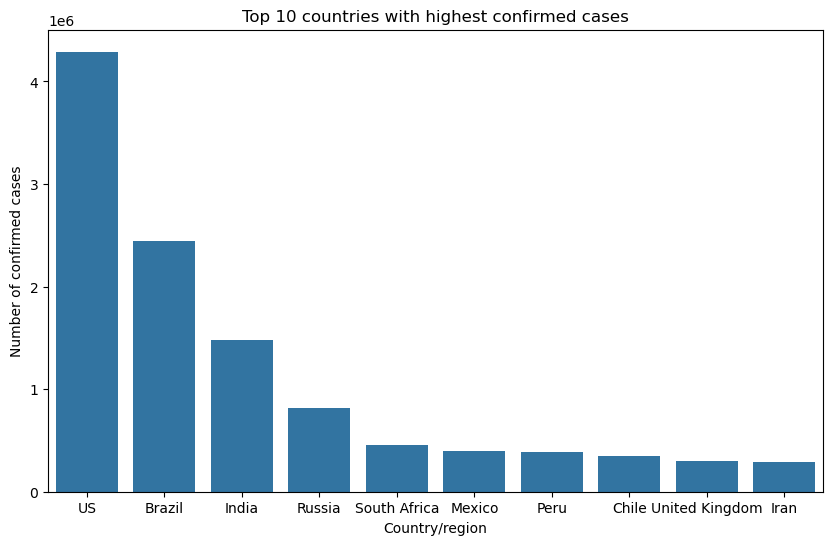

In [52]:
top_cases=country.sort_values(by="Confirmed", ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="Country/Region",y="Confirmed",data=top_cases)
plt.title("Top 10 countries with highest confirmed cases")
plt.xlabel("Country/region")
plt.ylabel("Number of confirmed cases")
plt.savefig("top_confirmed_cases.png")
plt.show()

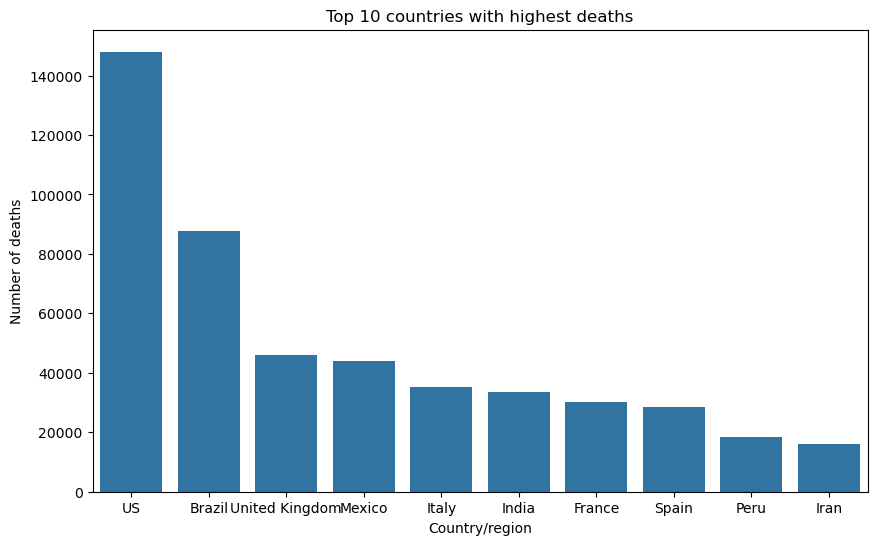

In [51]:
top_deaths=country.sort_values(by="Deaths",ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="Country/Region",y="Deaths",data=top_deaths)
plt.title("Top 10 countries with highest deaths")
plt.xlabel("Country/region")
plt.ylabel("Number of deaths")
plt.savefig("top_deaths.png")
plt.show()

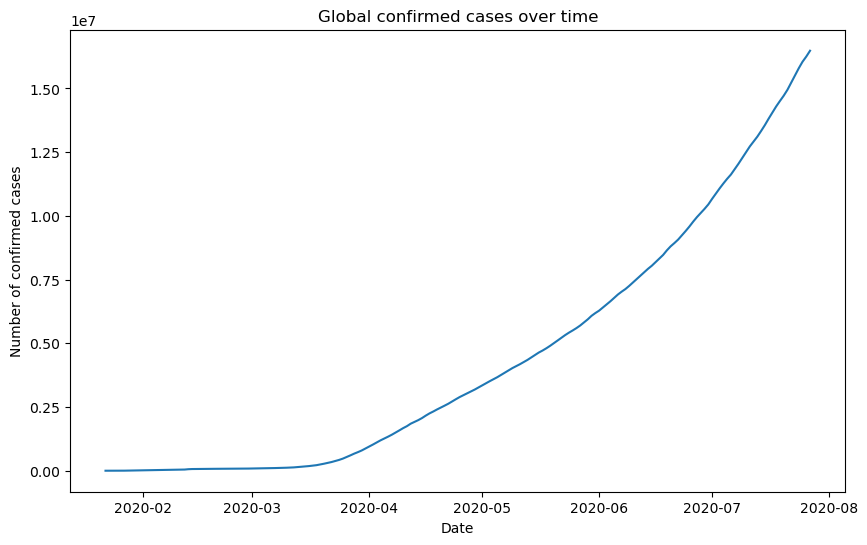

In [50]:
day["Date"]=pd.to_datetime(day["Date"])
plt.figure(figsize=(10,6))
sns.lineplot(x="Date",y="Confirmed",data=day)
plt.title("Global confirmed cases over time")
plt.xlabel("Date")
plt.ylabel("Number of confirmed cases")
plt.savefig("time_series_confirmed.png")
plt.show()

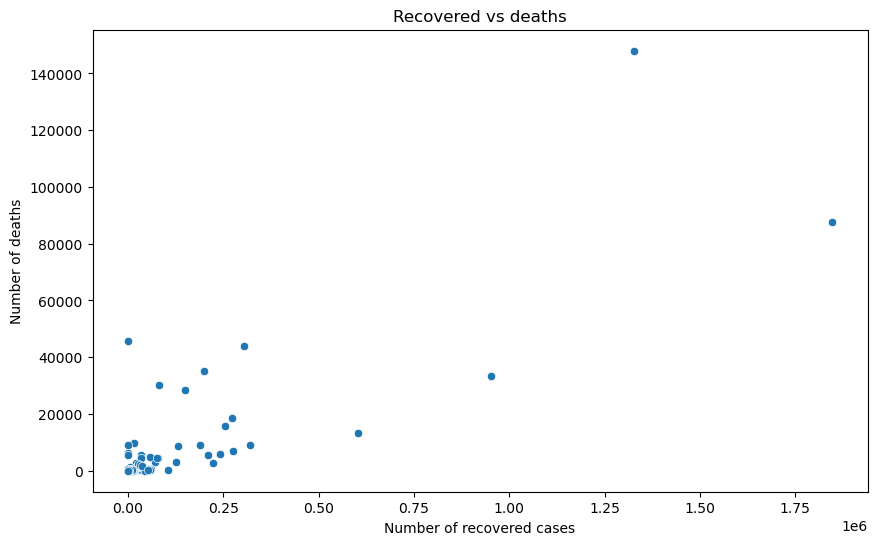

In [49]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Recovered",y="Deaths",data=country)
plt.title("Recovered vs deaths")
plt.xlabel("Number of recovered cases")
plt.ylabel("Number of deaths")
plt.savefig("recovered_vs_deaths.png")
plt.show()

In [39]:
country["Recovery_Rate"]=country["Recovered"]/country["Confirmed"]
top_country=country.sort_values(by="Recovery_Rate",ascending=False)
print(top_country[["Country/Region","Recovery_Rate"]].head(10))


    Country/Region  Recovery_Rate
49        Dominica       1.000000
75        Holy See       1.000000
69         Grenada       1.000000
48        Djibouti       0.983791
78         Iceland       0.983279
24          Brunei       0.978723
121    New Zealand       0.972383
136          Qatar       0.970173
105       Malaysia       0.965970
110      Mauritius       0.965116


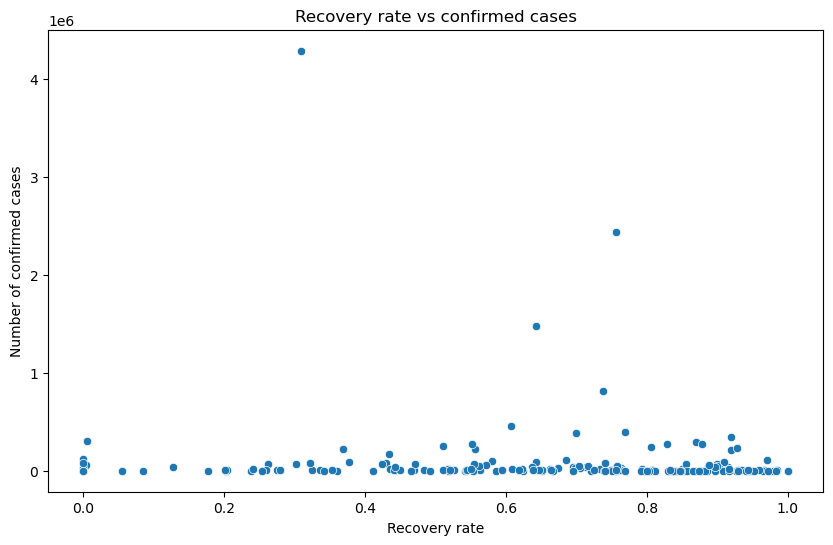

In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="Recovery_Rate",y="Confirmed",data=country)
plt.title("Recovery rate vs confirmed cases")
plt.xlabel("Recovery rate")
plt.ylabel("Number of confirmed cases") 
plt.savefig("recovery_rate_vs_confirmed.png")
plt.show()

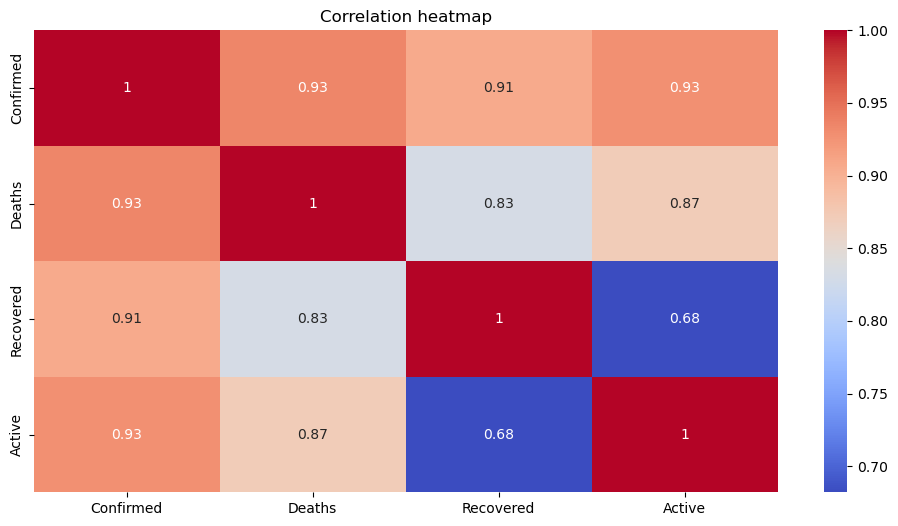

In [47]:
plt.figure(figsize=(12,6))
sns.heatmap(country[["Confirmed","Deaths","Recovered","Active"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

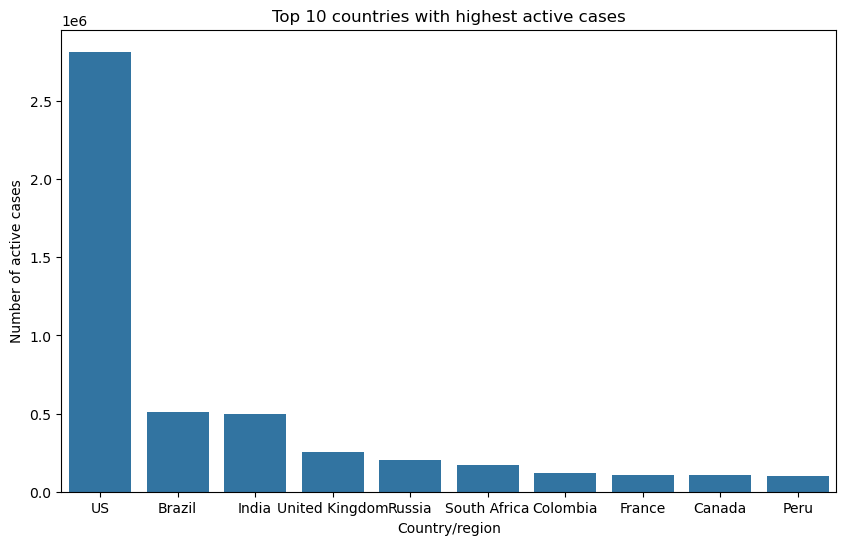

In [46]:
active=country.sort_values(by="Active",ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x="Country/Region",y="Active",data=active)
plt.title("Top 10 countries with highest active cases")
plt.xlabel("Country/region")
plt.ylabel("Number of active cases")
plt.savefig("top_active_cases.png")
plt.show()